In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import mlflow
import mlflow.sklearn
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

print("✅ Libraries imported")

c:\Users\USER\Documents\Python Project\venv\Lib\site-packages\pydantic\_internal\_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
c:\Users\USER\Documents\Python Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported


In [3]:
X_train = np.load("../artifacts/X_train_scaled.npy", allow_pickle=True)
X_test  = np.load("../artifacts/X_test_scaled.npy",  allow_pickle=True)
y_train = np.load("../artifacts/y_train.npy",         allow_pickle=True)
y_test  = np.load("../artifacts/y_test.npy",           allow_pickle=True)

feature_cols = joblib.load("../artifacts/feature_cols.pkl")

print(f"✅ Data loaded")
print(f"\n   X_train shape : {X_train.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   Features      : {feature_cols}")
print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"   {cls}: {cnt}")

✅ Data loaded

   X_train shape : (30888, 9)
   X_test shape  : (2000, 9)
   Features      : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power_W', 'Temp_Delta', 'Wear_Torque', 'Type_encoded']

Training class distribution:
   Critical: 7722
   Degraded: 7722
   Early Warning: 7722
   Normal: 7722


In [4]:
# Three models, each with a different strength
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="mlogloss",
        verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
}

print("✅ Three models defined:")
for name in models:
    print(f"   - {name}")

✅ Three models defined:
   - RandomForest
   - XGBoost
   - LightGBM


In [5]:
# Missing a Critical failure costs 10x more than a false alarm
# This is the business-relevant evaluation

def calculate_cost(y_true, y_pred):
    total_cost = 0
    for true, pred in zip(y_true, y_pred):
        if true == "Critical" and pred != "Critical":
            total_cost += 10   # missed failure — very expensive
        elif true != "Critical" and pred == "Critical":
            total_cost += 1    # false alarm — minor cost
    return total_cost

print("✅ Cost matrix defined")
print("   Missed Critical failure → cost of 10")
print("   False alarm             → cost of 1")

✅ Cost matrix defined
   Missed Critical failure → cost of 10
   False alarm             → cost of 1


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels to numbers for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("✅ Labels encoded:")
for i, cls in enumerate(le.classes_):
    print(f"   {i} → {cls}")

✅ Labels encoded:
   0 → Critical
   1 → Degraded
   2 → Early Warning
   3 → Normal


In [7]:
results = {}

mlflow.set_experiment("motorguard_training")

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    with mlflow.start_run(run_name=name):

        # ✅ USE ENCODED LABELS HERE
        model.fit(X_train, y_train_encoded)

        # Predict returns numbers — decode back to class names
        y_pred_encoded = model.predict(X_test)
        y_pred         = le.inverse_transform(y_pred_encoded)

        # Metrics
        f1     = f1_score(y_test, y_pred, average="macro")
        recall = recall_score(
            y_test, y_pred,
            labels=["Critical"],
            average="macro"
        )
        cost = calculate_cost(y_test, y_pred)

        # Log to MLflow
        mlflow.log_param("model", name)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("recall_critical", recall)
        mlflow.log_metric("business_cost", cost)
        mlflow.sklearn.log_model(model, name)

        # Store
        results[name] = {
            "model":           model,
            "y_pred":          y_pred,
            "f1_macro":        round(f1, 4),
            "recall_critical": round(recall, 4),
            "business_cost":   cost
        }

        print(f"\n📊 Classification Report:")
        print(classification_report(y_test, y_pred))
        print(f"✅ F1 Macro          : {f1:.4f}")
        print(f"✅ Recall (Critical) : {recall:.4f}")
        print(f"💰 Business Cost     : {cost}")


Training RandomForest...


2026/05/07 01:20:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 01:20:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Classification Report:
               precision    recall  f1-score   support

     Critical       0.50      0.72      0.59        25
     Degraded       0.92      1.00      0.96        22
Early Warning       0.70      0.83      0.76        23
       Normal       0.99      0.99      0.99      1930

     accuracy                           0.98      2000
    macro avg       0.78      0.88      0.82      2000
 weighted avg       0.98      0.98      0.98      2000

✅ F1 Macro          : 0.8243
✅ Recall (Critical) : 0.7200
💰 Business Cost     : 88

Training XGBoost...


2026/05/07 01:21:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 01:21:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Classification Report:
               precision    recall  f1-score   support

     Critical       0.54      0.76      0.63        25
     Degraded       0.92      1.00      0.96        22
Early Warning       0.81      0.74      0.77        23
       Normal       0.99      0.99      0.99      1930

     accuracy                           0.98      2000
    macro avg       0.82      0.87      0.84      2000
 weighted avg       0.99      0.98      0.98      2000

✅ F1 Macro          : 0.8386
✅ Recall (Critical) : 0.7600
💰 Business Cost     : 76

Training LightGBM...


2026/05/07 01:22:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 01:22:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Classification Report:
               precision    recall  f1-score   support

     Critical       0.64      0.72      0.68        25
     Degraded       1.00      1.00      1.00        22
Early Warning       0.86      0.78      0.82        23
       Normal       0.99      0.99      0.99      1930

     accuracy                           0.99      2000
    macro avg       0.87      0.87      0.87      2000
 weighted avg       0.99      0.99      0.99      2000

✅ F1 Macro          : 0.8729
✅ Recall (Critical) : 0.7200
💰 Business Cost     : 80


In [8]:

print("MODEL COMPARISON SUMMARY")

print(f"{'Model':<15} {'F1 Macro':<12} {'Recall Critical':<18} {'Business Cost'}")

for name, res in results.items():
    print(f"{name:<15} {res['f1_macro']:<12} {res['recall_critical']:<18} {res['business_cost']}")

# Select best model — lowest business cost wins
best_name = min(results, key=lambda x: results[x]["business_cost"])
best_model = results[best_name]["model"]

print(f"\n Best Model: {best_name}")
print(f"   Business Cost     : {results[best_name]['business_cost']}")
print(f"   F1 Macro          : {results[best_name]['f1_macro']}")
print(f"   Recall (Critical) : {results[best_name]['recall_critical']}")

MODEL COMPARISON SUMMARY
Model           F1 Macro     Recall Critical    Business Cost
RandomForest    0.8243       0.72               88
XGBoost         0.8386       0.76               76
LightGBM        0.8729       0.72               80

 Best Model: XGBoost
   Business Cost     : 76
   F1 Macro          : 0.8386
   Recall (Critical) : 0.76


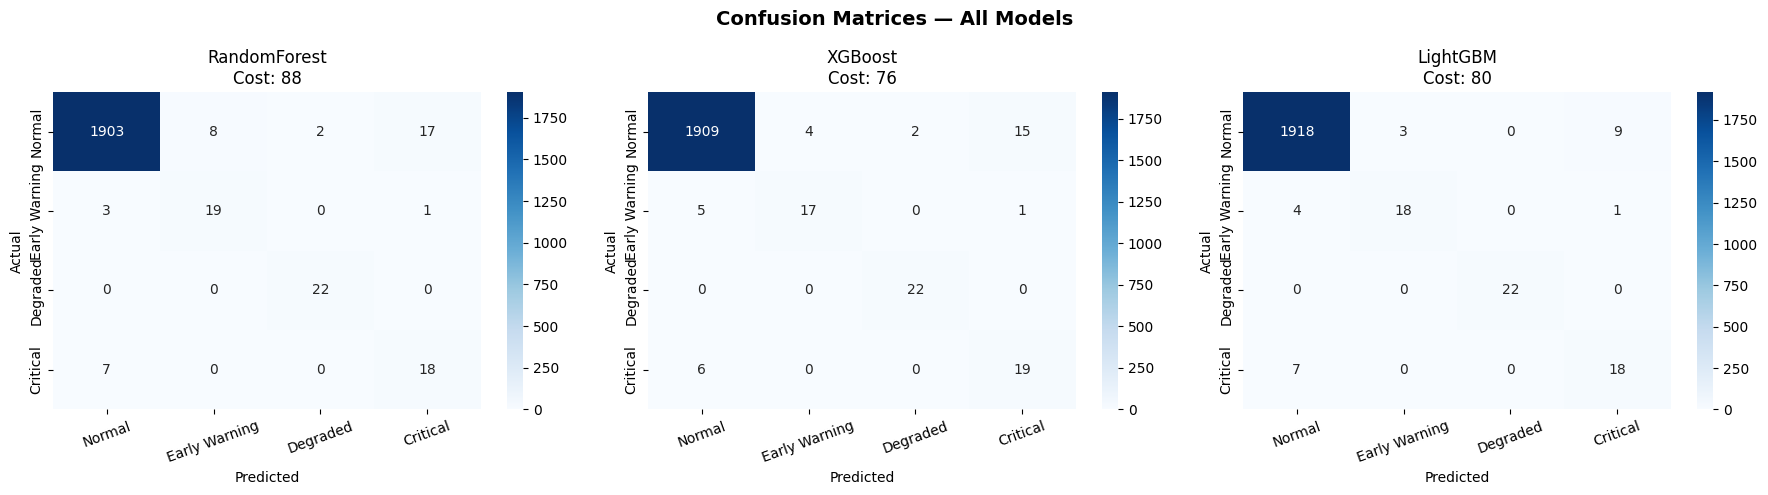

✅ Plot 5 saved — notebooks/plot5_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models",
             fontsize=14, fontweight="bold")

health_classes = ["Normal", "Early Warning", "Degraded", "Critical"]

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_pred"],
                          labels=health_classes)
    sns.heatmap(
        cm, annot=True, fmt="d",
        cmap="Blues", ax=axes[i],
        xticklabels=health_classes,
        yticklabels=health_classes
    )
    axes[i].set_title(f"{name}\nCost: {res['business_cost']}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../notebooks/plot5_confusion_matrices.png", dpi=150)
plt.show()
print("✅ Plot 5 saved — notebooks/plot5_confusion_matrices.png")

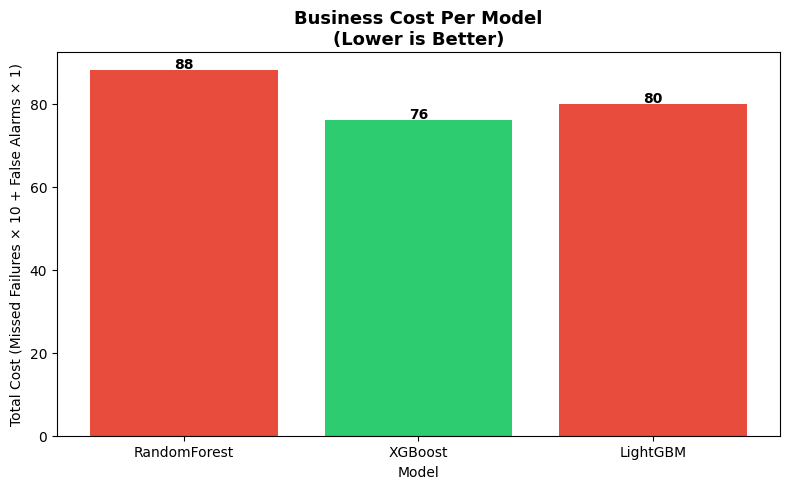

✅ Plot 6 saved — notebooks/plot6_business_cost.png


In [10]:
names  = list(results.keys())
costs  = [results[n]["business_cost"] for n in names]
colors = ["#e74c3c" if n != best_name else "#2ecc71" for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, costs, color=colors)
plt.title("Business Cost Per Model\n(Lower is Better)",
          fontsize=13, fontweight="bold")
plt.ylabel("Total Cost (Missed Failures × 10 + False Alarms × 1)")
plt.xlabel("Model")
for bar, cost in zip(bars, costs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(cost), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/plot6_business_cost.png", dpi=150)
plt.show()
print("✅ Plot 6 saved — notebooks/plot6_business_cost.png")

🔍 Generating SHAP explanations for XGBoost...


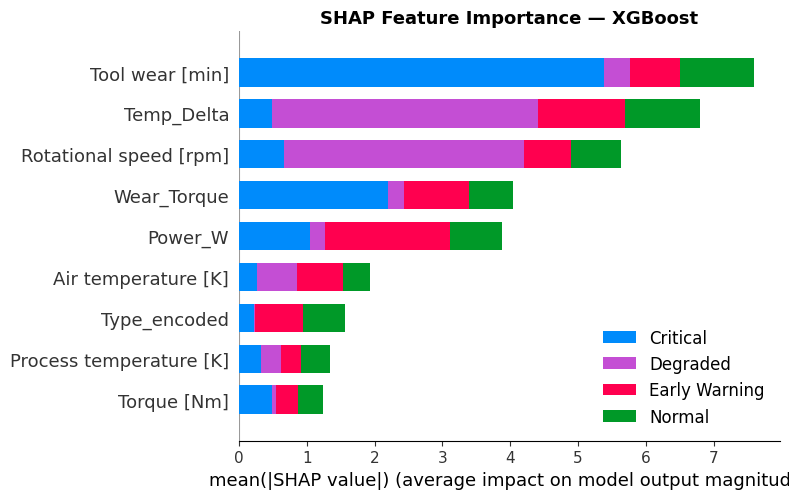

✅ Plot 7 saved — notebooks/plot7_shap_importance.png
✅ SHAP explainer saved to artifacts/shap_explainer.pkl


In [11]:
import shap
import matplotlib.pyplot as plt
import joblib

print(f"🔍 Generating SHAP explanations for {best_name}...")

explainer = shap.TreeExplainer(best_model)

# 1. This generates a 3D array for multiclass XGBoost
shap_values = explainer.shap_values(X_test)

# 2. THE FIX: Convert the 3D array into a list of 2D arrays (one per class)
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

class_names = ["Critical", "Degraded", "Early Warning", "Normal"]

# 3. Pass the new LIST into the plot, not the raw shap_values
shap.summary_plot(
    shap_values_list,  # 👈 Use the list here
    X_test,
    feature_names=feature_cols, # (You can leave this as a standard list now!)
    class_names=class_names,
    plot_type="bar",        
    show=False
)

plt.title(f"SHAP Feature Importance — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/plot7_shap_importance.png", dpi=150)
plt.show()

print("✅ Plot 7 saved — notebooks/plot7_shap_importance.png")

joblib.dump(explainer, "../artifacts/shap_explainer.pkl")
print("✅ SHAP explainer saved to artifacts/shap_explainer.pkl")

In [12]:
joblib.dump(best_model, "../artifacts/motorguard_model.pkl")
joblib.dump(le,         "../artifacts/label_encoder.pkl")
joblib.dump(feature_cols, "../artifacts/feature_cols.pkl")

print("✅ Best model saved    → artifacts/motorguard_model.pkl")
print("✅ Label encoder saved → artifacts/label_encoder.pkl")
print("✅ Feature cols saved  → artifacts/feature_cols.pkl")

print(f"\n📦 All artifacts in artifacts/ folder:")
for f in os.listdir("../artifacts"):
    print(f"   - {f}")

✅ Best model saved    → artifacts/motorguard_model.pkl
✅ Label encoder saved → artifacts/label_encoder.pkl
✅ Feature cols saved  → artifacts/feature_cols.pkl

📦 All artifacts in artifacts/ folder:
   - feature_cols.pkl
   - label_encoder.pkl
   - motorguard_model.pkl
   - scaler.pkl
   - shap_explainer.pkl
   - X_test_scaled.npy
   - X_train_scaled.npy
   - y_test.npy
   - y_train.npy


In [13]:

print(" TRAINING SUMMARY")
print(f"   Models trained      : 3 (RF, XGBoost, LightGBM)")
print(f"   Best model          : {best_name}")
print(f"   F1 Macro            : {results[best_name]['f1_macro']}")
print(f"   Recall (Critical)   : {results[best_name]['recall_critical']}")
print(f"   Business Cost       : {results[best_name]['business_cost']}")
print(f"   SHAP explainer      : Saved ✅")
print(f"   MLflow runs         : Logged ✅")
print(f"   Model artifact      : Saved ✅")



 TRAINING SUMMARY
   Models trained      : 3 (RF, XGBoost, LightGBM)
   Best model          : XGBoost
   F1 Macro            : 0.8386
   Recall (Critical)   : 0.76
   Business Cost       : 76
   SHAP explainer      : Saved ✅
   MLflow runs         : Logged ✅
   Model artifact      : Saved ✅


In [14]:
import numpy as np
import pandas as pd
import joblib

scaler       = joblib.load("../artifacts/scaler.pkl")
model        = joblib.load("../artifacts/motorguard_model.pkl")
le           = joblib.load("../artifacts/label_encoder.pkl")
feature_cols = joblib.load("../artifacts/feature_cols.pkl")

# Test extreme combinations
test_cases = [
    {"name": "Max Everything",      "type": 1, "air": 295, "proc": 315, "rpm": 1168, "torque": 76.6, "wear": 253},
    {"name": "Low RPM High Torque", "type": 1, "air": 295, "proc": 315, "rpm": 1168, "torque": 76.6, "wear": 200},
    {"name": "L-Type Max Strain",   "type": 1, "air": 300, "proc": 313, "rpm": 1200, "torque": 70.0, "wear": 240},
    {"name": "Power Too Low",       "type": 1, "air": 295, "proc": 315, "rpm": 1168, "torque":  3.8, "wear": 253},
    {"name": "Power Too High",      "type": 1, "air": 295, "proc": 308, "rpm": 2886, "torque": 76.6, "wear": 253},
    {"name": "Heat Dissipation",    "type": 2, "air": 305, "proc": 305, "rpm": 1300, "torque": 60.0, "wear": 150},
]

print(f"{'Scenario':<25} {'Prediction':<15} {'Confidence':<12} {'Probabilities'}")
print("-" * 80)

for case in test_cases:
    air   = case["air"]
    proc  = case["proc"]
    rpm   = case["rpm"]
    torq  = case["torque"]
    wear  = case["wear"]
    typ   = case["type"]

    power_w     = (2 * np.pi * rpm * torq) / 60
    temp_delta  = proc - air
    wear_torque = wear * torq

    row = pd.DataFrame([{
        "Type_encoded":            typ,
        "Air temperature [K]":     air,
        "Process temperature [K]": proc,
        "Rotational speed [rpm]":  rpm,
        "Torque [Nm]":             torq,
        "Tool wear [min]":         wear,
        "Power_W":                 power_w,
        "Temp_Delta":              temp_delta,
        "Wear_Torque":             wear_torque
    }])[feature_cols]

    scaled     = scaler.transform(row)
    pred_enc   = model.predict(scaled)[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    proba      = model.predict_proba(scaled)[0]
    confidence = proba.max() * 100
    proba_str  = " | ".join(
        [f"{le.classes_[i]}:{proba[i]*100:.0f}%" for i in range(len(le.classes_))]
    )

    print(f"{case['name']:<25} {pred_label:<15} {confidence:<12.1f} {proba_str}")

Scenario                  Prediction      Confidence   Probabilities
--------------------------------------------------------------------------------
Max Everything            Early Warning   99.9         Critical:0% | Degraded:0% | Early Warning:100% | Normal:0%
Low RPM High Torque       Early Warning   99.9         Critical:0% | Degraded:0% | Early Warning:100% | Normal:0%
L-Type Max Strain         Critical        100.0        Critical:100% | Degraded:0% | Early Warning:0% | Normal:0%
Power Too Low             Normal          87.4         Critical:1% | Degraded:0% | Early Warning:11% | Normal:87%
Power Too High            Early Warning   99.9         Critical:0% | Degraded:0% | Early Warning:100% | Normal:0%
Heat Dissipation          Degraded        99.9         Critical:0% | Degraded:100% | Early Warning:0% | Normal:0%


In [ ]:
# Run this in training notebook to confirm encoding
import joblib

le_type = joblib.load("../artifacts/label_encoder.pkl")
print("Target encoding:")
for i, cls in enumerate(le_type.classes_):
    print(f"   {i} → {cls}")

# Also print Type encoding manually
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("../data/processed_data.csv")
le_t = LabelEncoder()
le_t.fit(["H", "L", "M"])  # alphabetical
print("\nType encoding:")
for i, cls in enumerate(le_t.classes_):
    print(f"   {i} → {cls}")import joblib

le_type = joblib.load("../artifacts/label_encoder.pkl")
print("Target encoding:")
for i, cls in enumerate(le_type.classes_):
    print(f"   {i} → {cls}")

# Also print Type encoding manually
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("../data/processed_data.csv")
le_t = LabelEncoder()
le_t.fit(["H", "L", "M"])  # alphabetical
print("\nType encoding:")
for i, cls in enumerate(le_t.classes_):
    print(f"   {i} → {cls}")

Target encoding:
   0 → Critical
   1 → Degraded
   2 → Early Warning
   3 → Normal

Type encoding:
   0 → H
   1 → L
   2 → M
